<a href="https://colab.research.google.com/github/NurAyuL27/PCVK_Genap_2025/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **2. Berikut merupakan langkah-langkah yang dapat dilakukan:**

**b. Fungsi Konvolusi Tanpa Library OpenCV**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

def convolution2d(image, kernel, stride, padding):
    # Mendapatkan dimensi image dan kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Menambahkan padding ke image
    if padding > 0:
        image_padded = np.pad(image, padding, mode='constant', constant_values=0)
    else:
        image_padded = image

    # Menghitung dimensi output
    output_height = (image_height + 2*padding - kernel_height) // stride + 1
    output_width = (image_width + 2*padding - kernel_width) // stride + 1

    # Inisialisasi output
    output = np.zeros((output_height, output_width))

    # Proses konvolusi
    for y in range(0, output_height):
        for x in range(0, output_width):
            # Menghitung area yang akan dikonvolusi
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width

            # Ekstrak region dari image
            region = image_padded[y_start:y_end, x_start:x_end]

            # Melakukan konvolusi
            output[y, x] = np.sum(region * kernel)

    return output

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**d. Load Citra dan Konversi ke Grayscale**

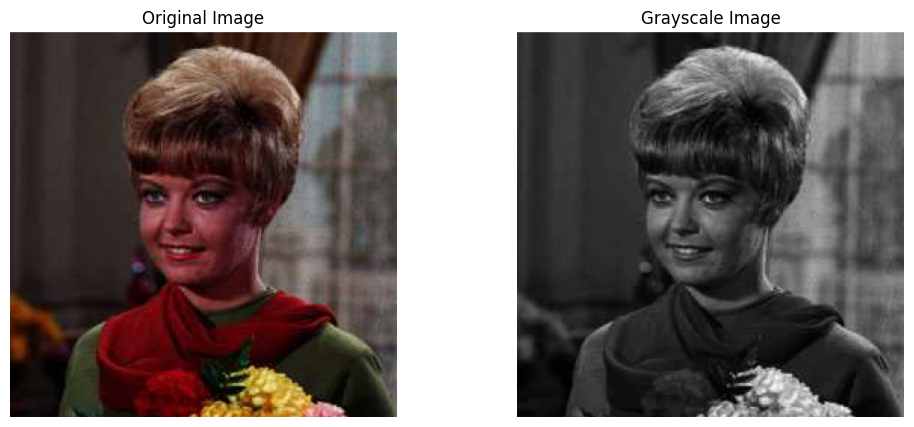

In [6]:
# Load citra dan konversi ke grayscale
img = cv.imread('/content/drive/MyDrive/female.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Menampilkan citra asli dan grayscale
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.show()

**e. Implementasi Berbagai Filter**

In [8]:

# Mendefinisikan kernel sharpening
print("\n" + "="*50)
print("KERNEL SHARPENING")
print("="*50)

# Kernel Sharpening
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

print("Kernel Sharpening:")
print(kernel_sharpen)
print(f"Dimensi kernel: {kernel_sharpen.shape}")


KERNEL SHARPENING
Kernel Sharpening:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]
Dimensi kernel: (3, 3)


**f. Aplikasi Filter dan Visualisasi Hasil**

HASIL KONVOLUSI FILTER SHARPEN


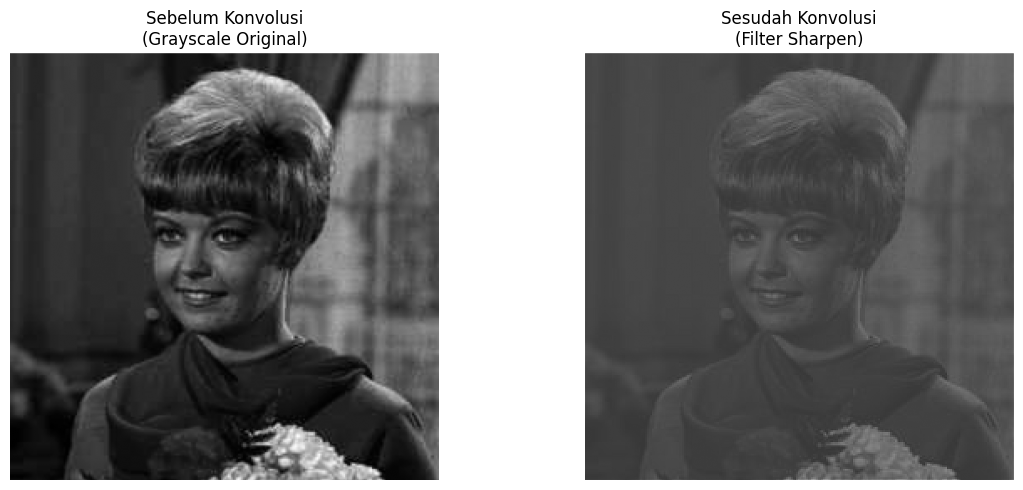

In [12]:
# f. Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil konvolusinya

print("HASIL KONVOLUSI FILTER SHARPEN")
print("=" * 50)

# Memanggil fungsi konvolusi dengan kernel sharpen
result_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)

# Normalisasi hasil untuk menampilkan
result_sharpen_normalized = cv.normalize(result_sharpen, None, 0, 255, cv.NORM_MINMAX)
result_sharpen_uint8 = result_sharpen_normalized.astype(np.uint8)

# Menampilkan hasil sebelum dan sesudah konvolusi
plt.figure(figsize=(12, 5))

# Sebelum konvolusi
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Sebelum Konvolusi\n(Grayscale Original)')
plt.axis('off')

# Sesudah konvolusi
plt.subplot(1, 2, 2)
plt.imshow(result_sharpen_uint8, cmap='gray')
plt.title('Sesudah Konvolusi\n(Filter Sharpen)')
plt.axis('off')

plt.tight_layout()
plt.show()

# **3. Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter berikut:**

HASIL BERBAGAI FILTER SPASIAL


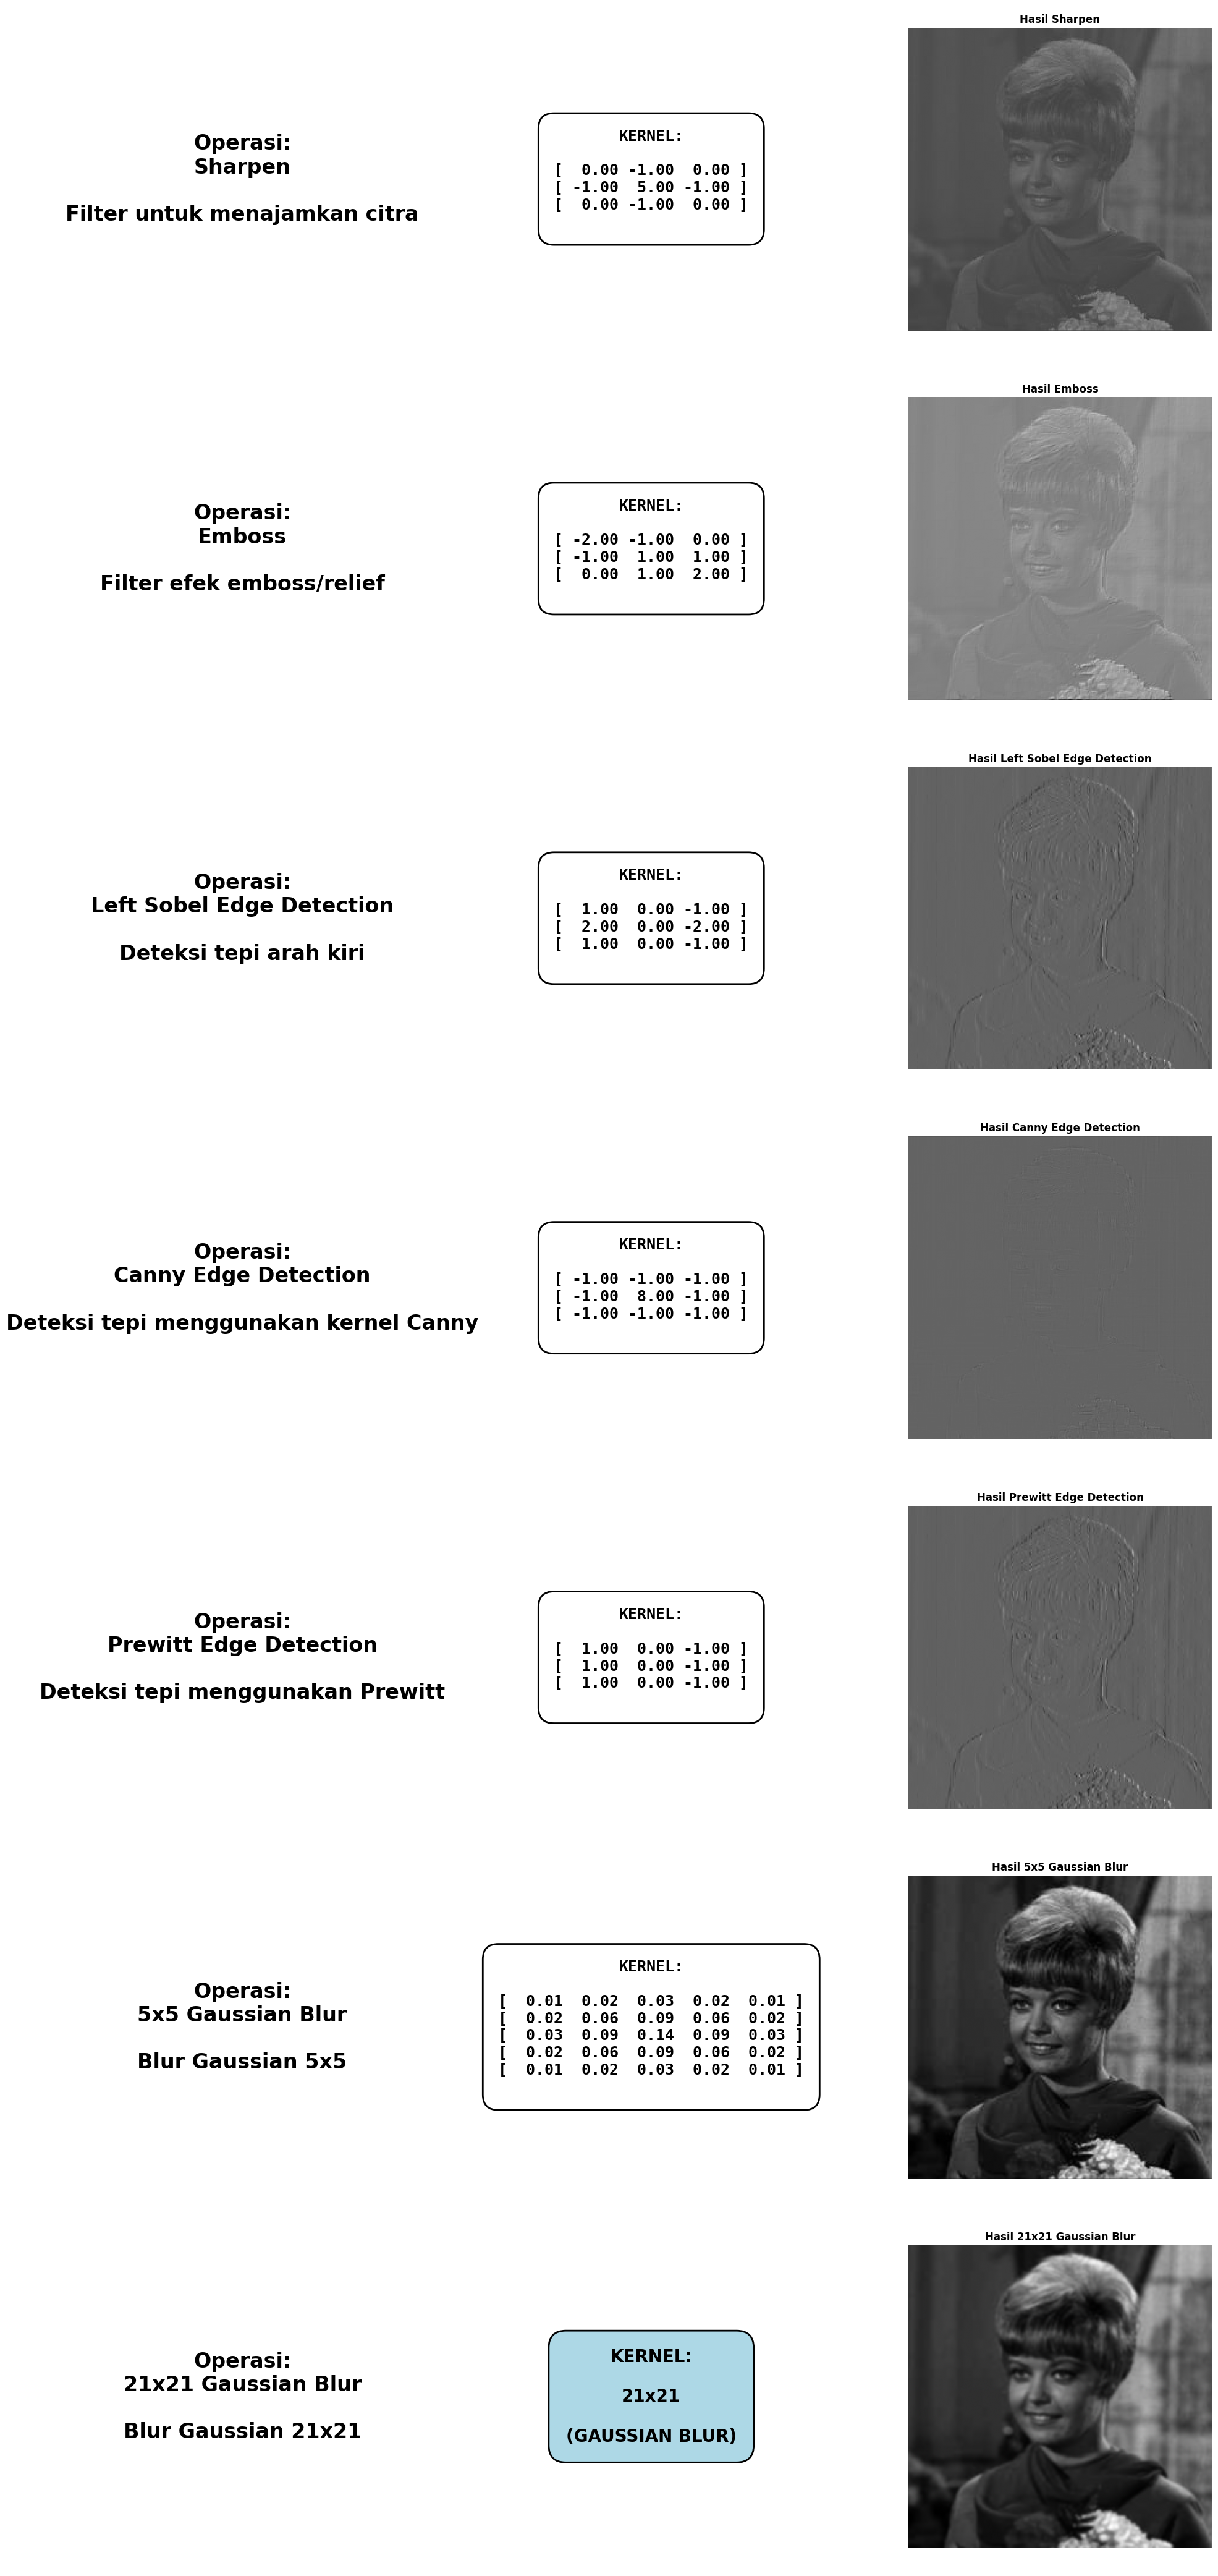


DETAIL KERNEL UNTUK FILTER BERUKURAN KECIL:

Sharpen:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]

Emboss:
[[-2 -1  0]
 [-1  1  1]
 [ 0  1  2]]

Left Sobel Edge Detection:
[[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]

Canny Edge Detection:
[[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]

Prewitt Edge Detection:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

5x5 Gaussian Blur:
[[0.00500788 0.01729958 0.02615146 0.01729958 0.00500788]
 [0.01729958 0.05976089 0.09033947 0.05976089 0.01729958]
 [0.02615146 0.09033947 0.13656459 0.09033947 0.02615146]
 [0.01729958 0.05976089 0.09033947 0.05976089 0.01729958]
 [0.00500788 0.01729958 0.02615146 0.01729958 0.00500788]]


In [17]:
# 3. Buat Image Filter untuk berbagai jenis filter

# Definisi semua kernel yang diminta
filters = {
    'Sharpen': {
        'kernel': np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]]),
        'description': 'Filter untuk menajamkan citra'
    },
    'Emboss': {
        'kernel': np.array([[-2, -1, 0],
                           [-1, 1, 1],
                           [0, 1, 2]]),
        'description': 'Filter efek emboss/relief'
    },
    'Left Sobel Edge Detection': {
        'kernel': np.array([[1, 0, -1],
                           [2, 0, -2],
                           [1, 0, -1]]),
        'description': 'Deteksi tepi arah kiri'
    },
    'Canny Edge Detection': {
        'kernel': np.array([[-1, -1, -1],
                           [-1, 8, -1],
                           [-1, -1, -1]]),
        'description': 'Deteksi tepi menggunakan kernel Canny'
    },
    'Prewitt Edge Detection': {
        'kernel': np.array([[1, 0, -1],
                           [1, 0, -1],
                           [1, 0, -1]]),
        'description': 'Deteksi tepi menggunakan Prewitt'
    }
}

# Fungsi untuk membuat Gaussian kernel custom
def create_gaussian_kernel(size, sigma=None):
    """Membuat Gaussian kernel dengan ukuran tertentu"""
    if sigma is None:
        sigma = 0.3 * ((size - 1) * 0.5 - 1) + 0.8

    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    gauss = np.exp(-0.5 * np.square(ax) / np.square(sigma))
    kernel = gauss / np.sum(gauss)
    return np.outer(kernel, kernel)

# Tambahkan Gaussian filters
gaussian_5x5 = create_gaussian_kernel(5)
gaussian_21x21 = create_gaussian_kernel(21)

filters['5x5 Gaussian Blur'] = {
    'kernel': gaussian_5x5,
    'description': 'Blur Gaussian 5x5'
}

filters['21x21 Gaussian Blur'] = {
    'kernel': gaussian_21x21,
    'description': 'Blur Gaussian 21x21'
}

# Proses semua filter dan buat tabel hasil
print("HASIL BERBAGAI FILTER SPASIAL")
print("=" * 80)

# Buat layout tabel
num_filters = len(filters)
fig = plt.figure(figsize=(20, 6 * num_filters))

for i, (filter_name, filter_data) in enumerate(filters.items()):
    # Aplikasikan konvolusi
    kernel = filter_data['kernel']
    result = convolution2d(img_gray, kernel, stride=1, padding=2)

    # Normalisasi hasil
    result_normalized = cv.normalize(result, None, 0, 255, cv.NORM_MINMAX)
    result_uint8 = result_normalized.astype(np.uint8)

    # Baris untuk setiap filter - 3 kolom
    # Kolom 1: Nama Operasi
    ax1 = plt.subplot(num_filters, 3, i*3 + 1)
    ax1.text(0.5, 0.5, f"Operasi:\n{filter_name}\n\n{filter_data['description']}",
             ha='center', va='center', fontsize=24, fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.axis('off')
    ax1.set_facecolor('#f0f0f0')

    # Kolom 2: Kernel
    ax2 = plt.subplot(num_filters, 3, i*3 + 2)
    if kernel.shape[0] <= 5:  # Tampilkan kernel jika ukuran kecil
        # Format kernel dengan font yang lebih besar
        kernel_str = "KERNEL:\n\n"
        for row in kernel:
            kernel_str += "["
            for val in row:
                kernel_str += f"{val:6.2f}"
            kernel_str += " ]\n"

        ax2.text(0.5, 0.5, kernel_str, ha='center', va='center', fontsize=18,
                family='monospace', fontweight='bold',
                bbox=dict(boxstyle="round,pad=1", facecolor="white", edgecolor="black", linewidth=2))
    else:
        # Untuk kernel besar, tampilkan informasi saja dengan font besar
        ax2.text(0.5, 0.5, f"KERNEL:\n\n{kernel.shape[0]}x{kernel.shape[1]}\n\n(GAUSSIAN BLUR)",
                ha='center', va='center', fontsize=20, fontweight='bold',
                bbox=dict(boxstyle="round,pad=1", facecolor="lightblue", edgecolor="black", linewidth=2))
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.axis('off')
    ax2.set_facecolor('#f0f8f0')

    # Kolom 3: Hasil Foto
    ax3 = plt.subplot(num_filters, 3, i*3 + 3)
    ax3.imshow(result_uint8, cmap='gray')
    ax3.set_title(f'Hasil {filter_name}', fontsize=12, fontweight='bold')
    ax3.axis('off')

plt.tight_layout()
plt.show()

# Tampilkan informasi detail untuk kernel kecil
print("\nDETAIL KERNEL UNTUK FILTER BERUKURAN KECIL:")
print("=" * 50)
for filter_name, filter_data in filters.items():
    kernel = filter_data['kernel']
    if kernel.shape[0] <= 5:
        print(f"\n{filter_name}:")
        print(kernel)